In [17]:
import pandas as pd
import time
import numpy as np

In [18]:
# def create_dataframe(csv_file_path, max_steps=365):
#     unique_users = set()
#     fraud_account = set()
    
#     chunk_size = 50000  # Larger chunks for better performance
#     for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
#         orig_users = chunk['nameOrig'].dropna().unique()
#         dest_users = chunk['nameDest'].dropna().unique()
#         unique_users.update(orig_users)
#         unique_users.update(dest_users)
        
#         # Clear chunk from memory explicitly
#         del chunk
    
#     unique_users = sorted(list(unique_users))
#     print(f"Found {len(unique_users)} unique users")
    
#     # Initialize DataFrame - this is our main memory usage
#     df = pd.DataFrame(index=range(max_steps), columns=unique_users, dtype=float)
    
#     # Track which users we've seen (much smaller than storing all transactions)
#     user_first_seen = {}  # user -> bool (whether we've seen them)
    
#     print("Processing transactions...")
    
#     # Second pass: populate DataFrame directly
#     for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
#         for _, row in chunk.iterrows():
#             step = int(row['step'])

#             # Process origin user
#             orig_user = row['nameOrig']
#             if pd.notna(orig_user):
#                 old_balance = float(row['oldBalanceOrig'])
#                 new_balance = float(row['newBalanceOrig'])
                
#                 if orig_user not in user_first_seen:
#                     # First time seeing this user - backfill with old balance
#                     if step > 0:
#                         df.loc[:step-1, orig_user] = old_balance
#                     user_first_seen[orig_user] = True
                
#                 # Update from current step onwards
#                 df.loc[step:, orig_user] = new_balance
            
#             # Process destination user
#             dest_user = row['nameDest']
#             if pd.notna(dest_user):
#                 old_balance = float(row['oldBalanceDest'])
#                 new_balance = float(row['newBalanceDest'])
                
#                 if dest_user not in user_first_seen:
#                     # First time seeing this user - backfill with old balance
#                     if step > 0:
#                         df.loc[:step-1, dest_user] = old_balance
#                     user_first_seen[dest_user] = True
                
#                 # Update from current step onwards
#                 df.loc[step:, dest_user] = new_balance
            
#             is_fraud = row['isFraud']
#             # Track frauds
#             if is_fraud == 1:
#                 fraud_account.add(orig_user)
#                 fraud_account.add(dest_user)
        
#         # Explicitly delete chunk to free memory
#         del chunk

#     account_prop = {
#         i: {
#             "original_id": user,
#             "fraud": user in fraud_account,
#             "class": str(user)[0]  # 'C', 'M', or 'B'
#         }
#         for i, user in enumerate(unique_users)
#     }
    
#     return df, account_prop

In [19]:
# csv_file = 'rawLog.csv'
# df, account_prop = create_dataframe(csv_file, max_steps=365)

In [33]:
from collections import defaultdict
from scipy.sparse import coo_matrix, lil_matrix

In [34]:
def create_dataframe_and_matrix(csv_file_path, max_steps=365):
    # First pass: identify unique users and fraud accounts
    print("First pass: Identifying users and fraud accounts...")
    unique_users = set()
    fraud_accounts = set()
    
    chunk_size = 100000
    for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
        # Get unique users
        orig_users = chunk['nameOrig'].dropna().unique()
        dest_users = chunk['nameDest'].dropna().unique()
        unique_users.update(orig_users)
        unique_users.update(dest_users)
        
        # Identify fraud accounts
        fraud_rows = chunk[chunk['isFraud'] == 1]
        fraud_accounts.update(fraud_rows['nameOrig'].dropna())
        fraud_accounts.update(fraud_rows['nameDest'].dropna())
        
        del chunk
    
    unique_users = sorted(list(unique_users))
    print(f"Found {len(unique_users)} unique users")
    print(f"Found {len(fraud_accounts)} fraud accounts")
    
    # Create user-to-id mapping
    user_to_id = {user: i for i, user in enumerate(unique_users)}
    max_account_id = len(unique_users)
    
    # Initialize DataFrame for balances
    df = pd.DataFrame(index=range(max_steps), columns=unique_users, dtype=float)
    
    # Initialize transaction tracking
    edge_weights = defaultdict(float)
    
    # Track which users we've seen for balance tracking
    user_first_seen = {}
    
    print("Second pass: Processing transactions and building matrices...")
    
    # Second pass: populate DataFrame and build transaction matrix
    for chunk in pd.read_csv(csv_file_path, chunksize=chunk_size):
        for _, row in chunk.iterrows():
            step = int(row['step'])
            amount = float(row['amount'])
            
            # Get users
            orig_user = row['nameOrig']
            dest_user = row['nameDest']
            
            # Build transaction matrix (only if both users are valid)
            if orig_user in user_to_id and dest_user in user_to_id:
                i = user_to_id[orig_user]
                j = user_to_id[dest_user]
                edge_weights[(i, j)] += amount
            
            # Process origin user for balance DataFrame
            old_balance = float(row['oldBalanceOrig'])
            new_balance = float(row['newBalanceOrig'])
                
            if orig_user not in user_first_seen:
                # First time seeing this user - backfill with old balance
                if step > 0:
                    df.loc[:step-1, orig_user] = old_balance
                user_first_seen[orig_user] = True
                
            # Update from current step onwards
            df.loc[step:, orig_user] = new_balance
            
            # Process destination user for balance DataFrame
            old_balance = float(row['oldBalanceDest'])
            new_balance = float(row['newBalanceDest'])
                
            if dest_user not in user_first_seen:
                # First time seeing this user - backfill with old balance
                if step > 0:
                    df.loc[:step-1, dest_user] = old_balance
                user_first_seen[dest_user] = True
                
            # Update from current step onwards
            df.loc[step:, dest_user] = new_balance
        
        del chunk
    
    # Convert edge_weights dict to sparse matrix
    print("Converting transaction data to sparse matrix...")
    rows, cols, data = zip(*[(i, j, amt) for (i, j), amt in edge_weights.items()])
    transaction_matrix = coo_matrix((data, (rows, cols)), 
                                      shape=(max_account_id, max_account_id)).tolil()
   
    # Create account properties dictionary
    account_prop = {
        i: {
            "original_id": user,
            "fraud": user in fraud_accounts,
            "class": str(user)[0]  # 'C', 'M', or 'B'
        }
        for i, user in enumerate(unique_users)
    }
    
    print(f"Balance DataFrame shape: {df.shape}")
    print(f"Transaction matrix shape: {transaction_matrix.shape}")
    print(f"Transaction matrix nnz (non-zero elements): {transaction_matrix.nnz}")
    
    return df, account_prop, transaction_matrix

In [35]:
l = [0.9999, 0.9999, 0.999]

In [36]:
df_2, account_prop, transaction_matrix = create_dataframe_and_matrix("rawLog.csv", max_steps=365)

First pass: Identifying users and fraud accounts...
Found 1021801 unique users
Found 201473 fraud accounts
Second pass: Processing transactions and building matrices...
Converting transaction data to sparse matrix...
Balance DataFrame shape: (365, 1021801)
Transaction matrix shape: (1021801, 1021801)
Transaction matrix nnz (non-zero elements): 106940546


In [37]:
df_2.head(10)

,B1988447823,C0000005496,C0000054889,C0000058813,C0000081914,C0000083322,C0000083959,C0000085703,C0000089516,C0000104605,...,M9999628233,M9999670810,M9999701974,M9999719791,M9999720797,M9999744556,M9999815922,M9999908723,M9999975948,M9999976390
0,0.000000e+00,46136.85,4.01,13.83,21.50,93.48,47.30,30921.39,84711.36,37.32,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,3.874802e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,0.00,-209101.19,0.00,-388387.69,-22334.81,0.00,-91103.59
2,4.450011e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,0.00,-209101.19,0.00,-388387.69,-22334.81,0.00,-91103.59
3,4.480594e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,0.00,-209101.19,0.00,-388387.69,-139917.52,0.00,-91103.59
4,4.480594e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,0.00,-209101.19,0.00,-388387.69,-139917.52,0.00,-91103.59
5,4.480594e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,0.00,-209101.19,0.00,-388387.69,-139917.52,0.00,-91103.59
6,5.445727e+07,46136.85,4.01,13.83,21.50,93.48,60597.69,30921.39,84711.36,37.32,...,-106446.66,0.00,0.00,-248888.54,-209101.19,0.00,-388387.69,-139917.52,0.00,-91103.59
7,1.322618e+08,50913.10,4.01,13.83,21.50,35982.99,60597.69,30921.39,275081.89,37.32,...,-106446.66,-276862.70,0.00,-484741.46,-429429.12,0.00,-388387.69,-214633.22,-368977.29,-181096.71
8,4.467203e+08,50913.10,26185.74,190186.42,185101.55,253780.90,60597.69,207715.70,456419.08,72642.56,...,-357785.31,-856259.52,-485516.73,-968090.46,-778046.09,-730008.84,-765202.98,-1172098.98,-939652.29,-321864.13
9,9.503598e+08,194043.85,224080.74,444338.84,185101.55,550601.86,248770.14,333257.43,1206595.67,143885.88,...,-1081732.50,-1819117.10,-616582.39,-1167896.03,-973290.06,-1548277.31,-1352553.55,-1619976.51,-1172581.88,-699413.15


In [38]:
Y = Y = df_2.T.values

In [39]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [40]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 19.131198270175013
Min: -4.729643441613526
Mean std per row (should be 1): 0.99


In [41]:
Theta_dict = {}

In [42]:
ROWS = Y_new.shape[0]
ROWS

1021801

In [43]:
from SQUIC_functions import *
from scipy import sparse

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.89e+02 nnz(S)/p=3.86e+00
* iter=1 time=2.72e+00 obj=1.72e+06 |delta(obj)|/obj=4.12e-01 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=2 
* iter=2 time=5.57e+00 obj=1.72e+06 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=9.98e+02 nnz(X,W)/p=[3.86

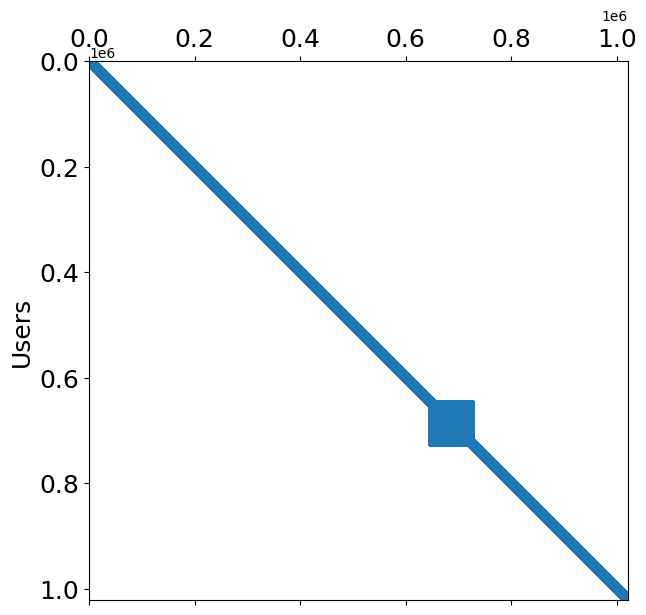

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.05e+03 nnz(S)/p=3.86e+00
* iter=1 time=2.84e+00 obj=1.72e+06 |delta(obj)|/obj=4.12e-01 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=2 
* iter=2 time=5.64e+00 obj=1.72e+06 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.06e+03 nnz(X,W)/p=[3.86

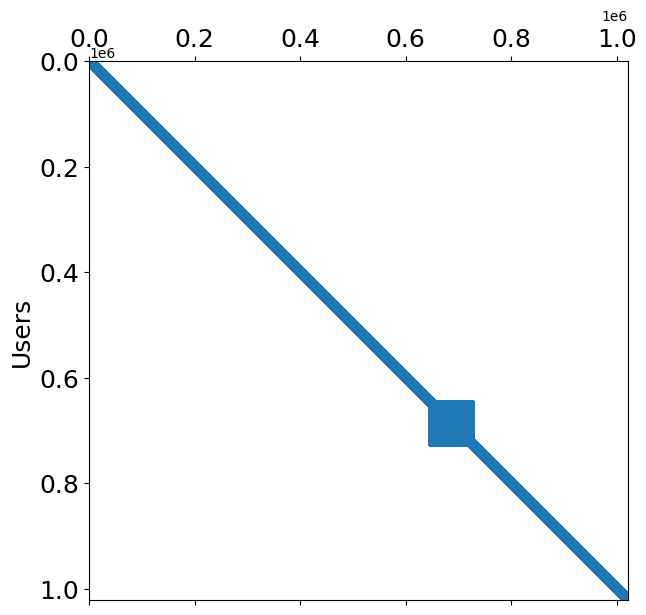

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.55e+02 nnz(S)/p=4.23e+00
* iter=1 time=2.96e+00 obj=1.72e+06 |delta(obj)|/obj=4.12e-01 nnz(X,L,W)/p=[4.23e+00 2.25e+00 1.00e+00] lns_iter=2 
* iter=2 time=6.26e+00 obj=1.72e+06 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[4.23e+00 2.25e+00 2.01e+00] lns_iter=2 
#SQUIC Finished: time=9.65e+02 nnz(X,W)/p=[4.23

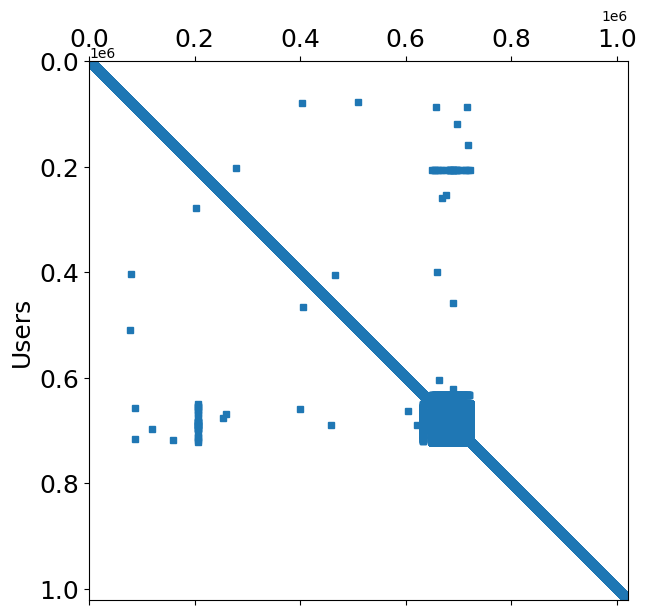

In [44]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    Theta, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    print(f"time required: {computation_time} seconds")

    Theta = sparse.csr_matrix(Theta) # store Theta as sparse
    Theta_dict[rho] = Theta

    nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

    print("Checking if symmetric")
    if check_symmetric_sparse(Theta_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        print_matrix(Theta_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        print_matrix(Theta_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        print_matrix(Theta_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.86e+00 time=1.04e+03
* iter=1 time=4.50e+00 obj=1.82e+06 |delta(obj)|/obj=4.43e-01 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=3 
* iter=2 time=7.86e+00 obj=1.73e+06 |delta(obj)|/obj=5.11e-02 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=2 
* iter=3 time=1.04e+01 obj=1.72e+06

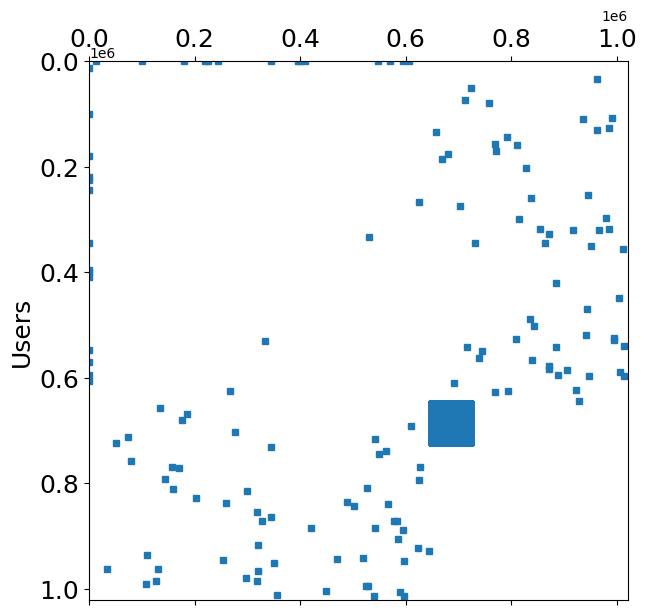

✅ Matrix is symmetric per rho 0.9999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.86e+00 time=1.02e+03
* iter=1 time=4.45e+00 obj=1.82e+06 |delta(obj)|/obj=4.43e-01 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=3 
* iter=2 time=7.06e+00 obj=1.73e+06 |delta(obj)|/obj=5.11e-02 nnz(X,L,W)/p=[3.86e+00 1.98e+00 1.00e+00] lns_iter=2

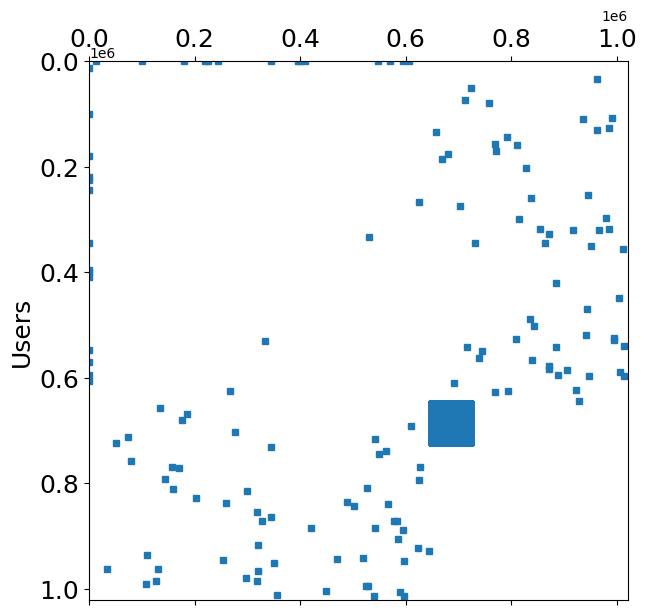

✅ Matrix is symmetric per rho 0.9999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.093177e+02
 Y:         1021801 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=4.23e+00 time=1.01e+03
* iter=1 time=4.74e+00 obj=1.82e+06 |delta(obj)|/obj=4.43e-01 nnz(X,L,W)/p=[4.23e+00 2.25e+00 1.00e+00] lns_iter=3 
* iter=2 time=8.39e+00 obj=1.73e+06 |delta(obj)|/obj=5.11e-02 nnz(X,L,W)/p=[4.23e+00 2.25e+00 1.00e+00] lns_iter=2

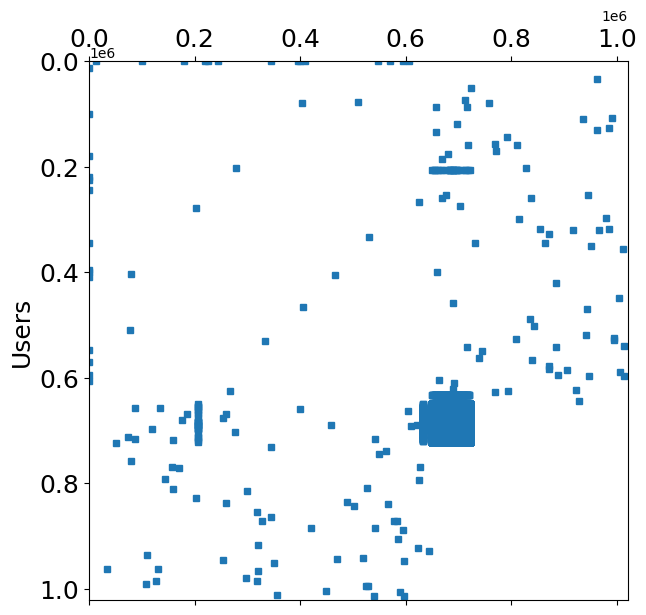

✅ Matrix is symmetric per rho 0.999


In [45]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W, end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=transaction_matrix)
    W_dict[rho] = sparse.csr_matrix(W)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    print_matrix(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [46]:
df_2.to_csv('1M_paysim.csv', index=False)

In [47]:
import json

with open('account_prop.json', 'w') as f:
    json.dump(account_prop, f)

In [49]:
from scipy import sparse

# Converti la matrice LIL in CSR
matrice_csr = transaction_matrix.tocsr()

# Ora puoi salvarla
sparse.save_npz('matrice_sparsa.npz', matrice_csr)

# matrice = sparse.load_npz('matrice_sparsa.npz')
